In [1]:
import numpy as np
from sklearn.linear_model import Perceptron

# Input data
X = np.array([
    [2, 1],
    [3, 2],
    [4, 3],
    [1, 1],
    [2, 2],
    [1, 2]
])

# Target
y = np.array([1, 1, 1, 0, 0, 0])

# Create Perceptron
model = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42
)

# Train model
model.fit(X, y)

# Prediction
prediction = model.predict(X)

print("Predictions:", prediction)
print("Actual:", y)

print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Predictions: [1 1 1 0 0 0]
Actual: [1 1 1 0 0 0]
Weights: [[ 0.2 -0.2]]
Bias: [-0.2]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("placement.csv")
print(data.shape)
data.head

(100, 3)


<bound method NDFrame.head of     cgpa  resume_score  placed
0   8.14          6.52       1
1   6.17          5.17       0
2   8.27          8.86       1
3   6.88          7.27       1
4   7.52          7.30       1
..   ...           ...     ...
95  6.33          6.38       0
96  8.23          7.76       1
97  6.65          7.78       0
98  8.14          5.63       1
99  6.09          6.61       0

[100 rows x 3 columns]>

<Axes: xlabel='cgpa', ylabel='resume_score'>

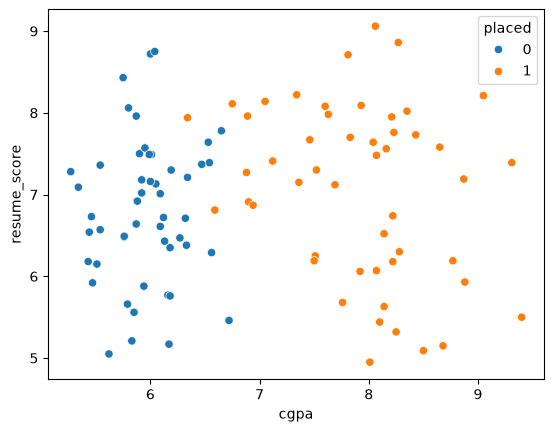

In [6]:
sns.scatterplot(
    x=data['cgpa'],
    y=data['resume_score'],
    hue=data['placed']
)

In [7]:
X= data.iloc[:,0:2]
y=data.iloc[:,-1]

In [8]:
from sklearn.linear_model import Perceptron
p = Perceptron()

In [9]:
p.fit(X,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [10]:
p.coef_

array([[ 40.26, -36.  ]])

In [13]:
p.intercept_

array([-25.])

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

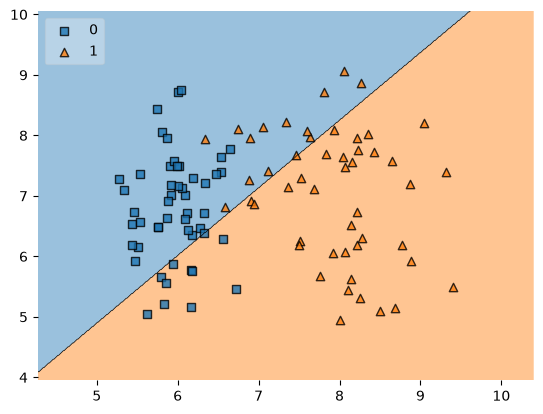

In [12]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values, y.values, clf=p, legend=2)

In [15]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

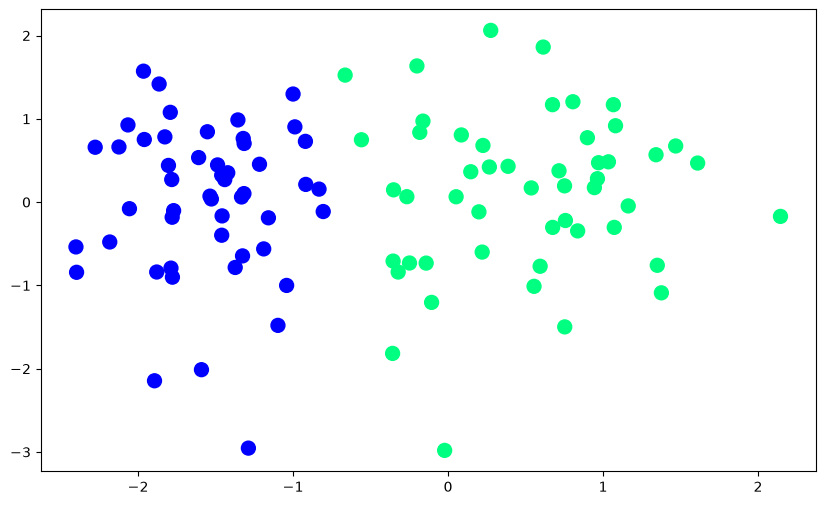

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [18]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [19]:
def step(z):
    return 1 if z>0 else 0

In [20]:
intercept_,coef_ = perceptron(X,y)

In [21]:
print(coef_)
print(intercept_)

[1.36851405 0.0933073 ]
1.0


In [22]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [23]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

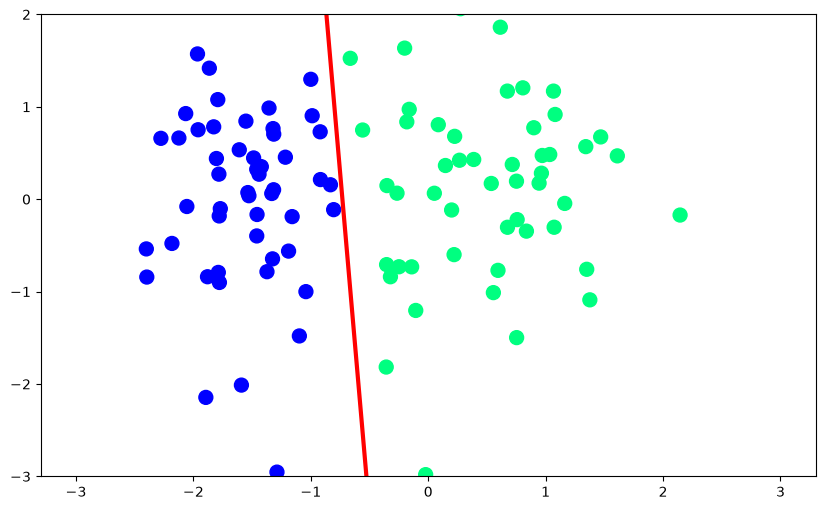

In [24]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)